# Deepfake Face Image Detection — EfficientNet-B0 Transfer Learning

**Only EfficientNet-B0 is included. No CNN baseline is included in this notebook.**

This notebook uses the **dataset-provided `8020` split only**.

Expected structure from the ZIP:
```text
Real vs Fake Faces/
└── 8020/
    ├── test/
    │   ├── fake/
    │   └── real/
    ├── train/
    │   ├── fake/
    │   └── real/
    └── valid/
        ├── fake/
        └── real/
```

Training plan:
- **Stage 1:** 5 epochs, pretrained EfficientNet-B0 backbone frozen; train only the new binary head.
- **Stage 2:** up to 10 more epochs, guaranteed to run for at least 1 epoch; unfreeze the **last 3 EfficientNet feature stages** and fine-tune at a lower learning rate.
- **Maximum:** 15 total epochs.
- **Early stopping:** restored in Stage 2 using validation-loss patience. The 95% validation-accuracy target can also stop Stage 2 early, but **fine-tuning is never skipped**.
- **Test set:** never used for training, early stopping, scheduler updates, or checkpoint selection. It is evaluated only after training/model selection.
- **Checkpoints:** latest checkpoint after every epoch; best overall checkpoint selected by validation loss.

### Why "last 3 stages" is not "only the 3rd-last layer"
`torchvision`'s `model.features` has 9 **top-level feature modules** indexed `0..8`, but several of those modules are `Sequential` containers holding multiple MBConv blocks. Therefore `features[-3:]` means **feature stages 6, 7, and 8**, not three individual convolutional layers. Stage 6 is itself a substantial stack of MBConv blocks.

For this 10,000-image dataset and free Colab GPU constraint, fine-tuning stages **6, 7, and 8** is the safer compute/overfitting trade-off than unfreezing 5 stages. The notebook prints parameter counts so this decision is visible before training.

In [1]:
# Cell 1 — Fix NumPy / scikit-learn environment

import os

ENV_MARKER = "/content/.nndl_environment_fixed"

if not os.path.exists(ENV_MARKER):
    print("First setup: installing compatible packages...")

    !pip -q install --upgrade --force-reinstall --no-cache-dir \
        "numpy==2.2.6" \
        "scikit-learn==1.7.2" \
        "matplotlib" \
        "Pillow"

    # Mark setup as completed BEFORE restarting.
    with open(ENV_MARKER, "w") as f:
        f.write("environment fixed")

    print("Packages installed.")
    print("Restarting runtime once so the new NumPy loads cleanly...")

    os.kill(os.getpid(), 9)

else:
    print("Environment already fixed — skipping package reinstall.")

    import numpy as np
    import sklearn
    import torch
    import torchvision
    from PIL import Image

    print("NumPy:", np.__version__)
    print("scikit-learn:", sklearn.__version__)
    print("PyTorch:", torch.__version__)
    print("Torchvision:", torchvision.__version__)
    print("Pillow:", Image.__version__)
    print("CUDA available:", torch.cuda.is_available())

    if torch.cuda.is_available():
        print("GPU:", torch.cuda.get_device_name(0))



# # Cell 1 — Install / fix packages and verify environment

# !pip -q install --upgrade --no-cache-dir \
#     "numpy==2.2.6" \
#     "scikit-learn==1.7.2" \
#     "matplotlib" \
#     "Pillow"

# # Imports
# import numpy as np
# import sklearn
# import torch
# import torchvision
# from PIL import Image

# print("NumPy:", np.__version__)
# print("scikit-learn:", sklearn.__version__)
# print("PyTorch:", torch.__version__)
# print("Torchvision:", torchvision.__version__)
# print("Pillow:", Image.__version__)
# print("CUDA available:", torch.cuda.is_available())

# if torch.cuda.is_available():
#     print("GPU:", torch.cuda.get_device_name(0))

Environment already fixed — skipping package reinstall.
NumPy: 2.2.6
scikit-learn: 1.7.2
PyTorch: 2.11.0+cu130
Torchvision: 0.26.0+cu130
Pillow: 12.3.0
CUDA available: True
GPU: Tesla T4


In [2]:
# Cell 2 — Mount Google Drive and define project paths
from google.colab import drive
drive.mount('/content/drive')

PROJECT_DIR = "/content/drive/MyDrive/NNDL_Deepfake_Project"
DATA_DIR = f"{PROJECT_DIR}/dataset"
CHECKPOINT_DIR = f"{PROJECT_DIR}/checkpoints"
RESULTS_DIR = f"{PROJECT_DIR}/results"

import os
for d in [PROJECT_DIR, DATA_DIR, CHECKPOINT_DIR, RESULTS_DIR]:
    os.makedirs(d, exist_ok=True)

print("Dataset folder:", DATA_DIR)
print("Checkpoint folder:", CHECKPOINT_DIR)
print("Results folder:", RESULTS_DIR)

print("\nFiles currently in dataset folder:")
for name in os.listdir(DATA_DIR):
    print(" -", name)


Mounted at /content/drive
Dataset folder: /content/drive/MyDrive/NNDL_Deepfake_Project/dataset
Checkpoint folder: /content/drive/MyDrive/NNDL_Deepfake_Project/checkpoints
Results folder: /content/drive/MyDrive/NNDL_Deepfake_Project/results

Files currently in dataset folder:
 - Real vs Fake Faces.zip


In [3]:
# Cell 3 — Extract the ZIP into the Colab runtime (not Drive)
# The ZIP stays safely in Drive. The extracted images are placed in /content for faster I/O.

import glob, zipfile, os

zip_files = glob.glob(os.path.join(DATA_DIR, "*.zip"))
if not zip_files:
    raise FileNotFoundError(
        f"No .zip file found in {DATA_DIR}. Put 'Real vs Fake Faces.zip' inside the dataset folder."
    )

preferred = [p for p in zip_files if "Real vs Fake Faces".lower() in os.path.basename(p).lower()]
ZIP_PATH = preferred[0] if preferred else zip_files[0]

EXTRACT_DIR = "/content/real_fake_faces"

if os.path.exists(EXTRACT_DIR) and os.path.isdir(EXTRACT_DIR):
    print("Existing extraction found:", EXTRACT_DIR)
else:
    print("Extracting:", ZIP_PATH)
    with zipfile.ZipFile(ZIP_PATH, "r") as z:
        bad = z.testzip()
        if bad is not None:
            raise RuntimeError(f"ZIP integrity check failed at member: {bad}")
        z.extractall(EXTRACT_DIR)
    print("Extraction complete.")

print("Runtime dataset location:", EXTRACT_DIR)

Extracting: /content/drive/MyDrive/NNDL_Deepfake_Project/dataset/Real vs Fake Faces.zip
Extraction complete.
Runtime dataset location: /content/real_fake_faces


In [4]:
# Cell 4 — Inspect the extracted dataset structure
from pathlib import Path


def print_tree(root, max_depth=4):
    root = Path(root)
    for path in sorted(root.rglob("*")):
        rel = path.relative_to(root)
        if len(rel.parts) <= max_depth:
            indent = "  " * (len(rel.parts) - 1)
            prefix = "📁" if path.is_dir() else "📄"
            print(f"{indent}{prefix} {path.name}")

print_tree(EXTRACT_DIR, max_depth=4)

📁 Real vs Fake Faces
  📁 6040
    📁 test
      📁 fake
      📁 real
    📁 train
      📁 fake
      📁 real
    📁 valid
      📁 fake
      📁 real
  📁 7030
    📁 test
      📁 fake
      📁 real
    📁 train
      📁 fake
      📁 real
    📁 valid
      📁 fake
      📁 real
  📁 7525
    📁 test
      📁 fake
      📁 real
    📁 train
      📁 fake
      📁 real
    📁 valid
      📁 fake
      📁 real
  📁 8020
    📁 test
      📁 fake
      📁 real
    📁 train
      📁 fake
      📁 real
    📁 valid
      📁 fake
      📁 real


In [5]:
# Cell 5 — Select ONLY the exact dataset-provided 8020 split
# Do not create a split and do not fall back to 70/30, 75/25, etc.
# The validation folder in the supplied ZIP is named `valid`.

from pathlib import Path
import os

EXPECTED_CLASSES = {"fake", "real"}


def has_exact_class_folders(path):
    path = Path(path)
    if not path.is_dir():
        return False
    class_dirs = {p.name.lower() for p in path.iterdir() if p.is_dir()}
    return class_dirs == EXPECTED_CLASSES


def find_8020_split(root):
    root = Path(root)
    exact = [p for p in [root] + list(root.rglob("*")) if p.is_dir() and p.name.lower() == "8020"]

    for p in exact:
        children = {x.name.lower(): x for x in p.iterdir() if x.is_dir()}
        required = {"train", "valid", "test"}
        if required.issubset(children) and all(has_exact_class_folders(children[s]) for s in required):
            return p

    raise RuntimeError(
        "Could not find the exact folder named '8020' containing train/fake+real, "
        "valid/fake+real, and test/fake+real. Run Cell 4 and inspect the tree. "
        "This notebook intentionally refuses to use another split."
    )


split_root = find_8020_split(EXTRACT_DIR)
TRAIN_DIR = split_root / "train"
VAL_DIR = split_root / "valid"
TEST_DIR = split_root / "test"

print("SELECTED SPLIT: PROVIDED 8020 ONLY")
print("Split root:", split_root)
print("Train:", TRAIN_DIR)
print("Validation: ", VAL_DIR, "(source folder name: valid)")
print("Test:", TEST_DIR)

for split_name, split_dir in [("train", TRAIN_DIR), ("valid", VAL_DIR), ("test", TEST_DIR)]:
    assert split_dir.is_dir(), f"Missing {split_name} directory: {split_dir}"
    assert has_exact_class_folders(split_dir), f"{split_name} must contain exactly fake and real folders"

assert TRAIN_DIR != VAL_DIR != TEST_DIR

SELECTED SPLIT: PROVIDED 8020 ONLY
Split root: /content/real_fake_faces/Real vs Fake Faces/8020
Train: /content/real_fake_faces/Real vs Fake Faces/8020/train
Validation:  /content/real_fake_faces/Real vs Fake Faces/8020/valid (source folder name: valid)
Test: /content/real_fake_faces/Real vs Fake Faces/8020/test


## Data integrity checks

The next cell performs two one-time checks required for a clean experiment:
1. **Corrupted-image check** using Pillow.
2. **Exact duplicate check** using SHA-256 hashes, including across train/valid/test.

An exact duplicate crossing a split boundary is reported because it can make a held-out test result misleading. This does not use any test accuracy or model output.

In [6]:
# Cell 6 — Corrupted-image and exact-duplicate checks
from PIL import Image, ImageFile
from collections import defaultdict
import hashlib, json, time

ImageFile.LOAD_TRUNCATED_IMAGES = False
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp", ".tif", ".tiff"}


def image_files(folder):
    return sorted(p for p in Path(folder).rglob("*") if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS)


def sha256_file(path, chunk_size=1024 * 1024):
    h = hashlib.sha256()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(chunk_size), b""):
            h.update(chunk)
    return h.hexdigest()

start = time.time()
corrupt = []
hash_to_paths = defaultdict(list)
split_counts = {}

for split_name, split_dir in [("train", TRAIN_DIR), ("valid", VAL_DIR), ("test", TEST_DIR)]:
    counts = {}
    for class_name in ["fake", "real"]:
        paths = image_files(split_dir / class_name)
        counts[class_name] = len(paths)
        for p in paths:
            try:
                with Image.open(p) as im:
                    im.verify()
                # Reopen and force decode to catch files that verify but fail on load.
                with Image.open(p) as im:
                    im.convert("RGB").load()
            except Exception as e:
                corrupt.append({"path": str(p), "error": repr(e)})
            hash_to_paths[sha256_file(p)].append(str(p))
    split_counts[split_name] = counts

cross_split_duplicates = []
same_split_duplicates = []
same_split_cross_class_duplicates = []
for digest, paths in hash_to_paths.items():
    if len(paths) > 1:
        split_names = {Path(p).parts[-3].lower() for p in paths}
        class_names = {Path(p).parts[-2].lower() for p in paths}
        item = {"sha256": digest, "paths": paths}
        if len(split_names) > 1:
            cross_split_duplicates.append(item)
        else:
            same_split_duplicates.append(item)
            if len(class_names) > 1:
                same_split_cross_class_duplicates.append(item)

print("Image counts:", json.dumps(split_counts, indent=2))
print("Corrupted/unreadable images:", len(corrupt))
print("Exact duplicate groups within a split:", len(same_split_duplicates))
print("Exact duplicate groups crossing train/valid/test:", len(cross_split_duplicates))
print("Exact duplicate groups crossing fake/real inside one split:", len(same_split_cross_class_duplicates))
print(f"Integrity scan time: {time.time() - start:.1f}s")

if corrupt:
    print("\nFirst corrupted files:")
    for item in corrupt[:10]:
        print(item)
    raise RuntimeError("Corrupted images were found. Fix the dataset before training.")

if cross_split_duplicates:
    print("\nWARNING: exact duplicates cross split boundaries. First groups:")
    for item in cross_split_duplicates[:10]:
        print(item)
    raise RuntimeError("Exact duplicate image content exists across train/valid/test. Refusing to train until this is reviewed.")

if same_split_cross_class_duplicates:
    print("\nWARNING: exact duplicate content appears in both fake and real folders inside one split:")
    for item in same_split_cross_class_duplicates[:10]:
        print(item)
    raise RuntimeError("The same exact image bytes appear under both fake and real. Refusing to train until this is reviewed.")

with open(os.path.join(RESULTS_DIR, "dataset_integrity_report.json"), "w") as f:
    json.dump({
        "split_counts": split_counts,
        "corrupt": corrupt,
        "same_split_duplicate_groups": same_split_duplicates,
        "same_split_cross_class_duplicate_groups": same_split_cross_class_duplicates,
        "cross_split_duplicate_groups": cross_split_duplicates,
    }, f, indent=2)

print("\nIntegrity checks passed. Report saved to:", os.path.join(RESULTS_DIR, "dataset_integrity_report.json"))


Image counts: {
  "train": {
    "fake": 4000,
    "real": 4000
  },
  "valid": {
    "fake": 500,
    "real": 500
  },
  "test": {
    "fake": 500,
    "real": 500
  }
}
Corrupted/unreadable images: 0
Exact duplicate groups within a split: 0
Exact duplicate groups crossing train/valid/test: 0
Exact duplicate groups crossing fake/real inside one split: 0
Integrity scan time: 9.2s

Integrity checks passed. Report saved to: /content/drive/MyDrive/NNDL_Deepfake_Project/results/dataset_integrity_report.json


In [7]:
# Cell 7 — Reproducibility, device, and training configuration
import random, numpy as np, torch

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

BATCH_SIZE = 32
NUM_WORKERS = 2
IMAGE_SIZE = 224

# Training budget: up to 10 head epochs + up to 15 fine-tuning epochs = 25 total.
# Stage 1 and Stage 2 both use early stopping with patience=3.
STAGE1_EPOCHS = 10
STAGE2_MAX_EPOCHS = 15
TOTAL_EPOCHS = STAGE1_EPOCHS + STAGE2_MAX_EPOCHS
EARLY_STOPPING_PATIENCE = 3
MIN_STAGE2_EPOCHS_BEFORE_EARLY_STOP = 3

HEAD_LR = 1e-3
FINETUNE_LR = 1e-4
WEIGHT_DECAY = 1e-4

# Fine-tune only the last 3 top-level EfficientNet feature stages: 6, 7, 8.
UNFREEZE_LAST_N_FEATURE_STAGES = 3

print("Device:", DEVICE)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
print({
    "batch_size": BATCH_SIZE,
    "image_size": IMAGE_SIZE,
    "stage1_epochs": STAGE1_EPOCHS,
    "stage2_max_epochs": STAGE2_MAX_EPOCHS,
    "total_epoch_budget": TOTAL_EPOCHS,
    "early_stopping_patience": EARLY_STOPPING_PATIENCE,
    "minimum_stage2_epochs_before_early_stop": MIN_STAGE2_EPOCHS_BEFORE_EARLY_STOP,
    "head_lr": HEAD_LR,
    "finetune_lr": FINETUNE_LR,
    "unfreeze_last_n_feature_stages": UNFREEZE_LAST_N_FEATURE_STAGES,
})

Device: cuda
GPU: Tesla T4
{'batch_size': 32, 'image_size': 224, 'stage1_epochs': 10, 'stage2_max_epochs': 15, 'total_epoch_budget': 25, 'early_stopping_patience': 3, 'minimum_stage2_epochs_before_early_stop': 3, 'head_lr': 0.001, 'finetune_lr': 0.0001, 'unfreeze_last_n_feature_stages': 3}


In [8]:
# Cell 8 — Image preprocessing, ImageFolder mapping, and DataLoaders
# TRAIN: augmentation only.
# VALID/TEST: deterministic preprocessing only.
# TEST loader exists, but is not passed into training/model-selection code.

from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from pathlib import Path

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomResizedCrop(IMAGE_SIZE, scale=(0.85, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.10),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

eval_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.CenterCrop(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

train_dataset = datasets.ImageFolder(str(TRAIN_DIR), transform=train_transform)
val_dataset = datasets.ImageFolder(str(VAL_DIR), transform=eval_transform)
test_dataset = datasets.ImageFolder(str(TEST_DIR), transform=eval_transform)

EXPECTED_CLASS_TO_IDX = {"fake": 0, "real": 1}
for split_name, ds in [("train", train_dataset), ("valid", val_dataset), ("test", test_dataset)]:
    print(f"{split_name} ImageFolder class_to_idx:", ds.class_to_idx)
    assert ds.class_to_idx == EXPECTED_CLASS_TO_IDX, (
        f"Unexpected {split_name} class mapping: {ds.class_to_idx}. "
        "Expected fake=0, real=1."
    )

FAKE_IDX = EXPECTED_CLASS_TO_IDX["fake"]
REAL_IDX = EXPECTED_CLASS_TO_IDX["real"]

# Explicit model-target convention:
# ImageFolder raw labels: fake=0, real=1
# Model BCE target:       fake=1, real=0
print("RAW ImageFolder mapping : fake=0, real=1")
print("MODEL binary target      : FAKE=1, REAL=0")

print("\nDataset sizes:")
print("Train:", len(train_dataset))
print("Valid:", len(val_dataset))
print("Test :", len(test_dataset))


def seed_worker(worker_id):
    worker_seed = SEED + worker_id
    np.random.seed(worker_seed)
    random.seed(worker_seed)

loader_generator = torch.Generator()
loader_generator.manual_seed(SEED)

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available(),
    worker_init_fn=seed_worker, generator=loader_generator
)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available(),
    worker_init_fn=seed_worker
)
test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available(),
    worker_init_fn=seed_worker
)

train ImageFolder class_to_idx: {'fake': 0, 'real': 1}
valid ImageFolder class_to_idx: {'fake': 0, 'real': 1}
test ImageFolder class_to_idx: {'fake': 0, 'real': 1}
RAW ImageFolder mapping : fake=0, real=1
MODEL binary target      : FAKE=1, REAL=0

Dataset sizes:
Train: 8000
Valid: 1000
Test : 1000


In [9]:
# Cell 9 — HARD LABEL VERIFICATION (do not skip this cell)
# This independently verifies folder -> ImageFolder raw label -> model target.
# It does NOT rely on the physical order in Windows Explorer.

from collections import Counter


def verify_dataset_labels(split_name, dataset, split_dir):
    split_dir = Path(split_dir)
    print(f"\n===== {split_name.upper()} LABEL VERIFICATION =====")
    print("ImageFolder class_to_idx:", dataset.class_to_idx)
    assert dataset.class_to_idx == {"fake": 0, "real": 1}

    manual_counts = {}
    raw_counts = Counter(label for _, label in dataset.samples)

    for class_name, expected_raw_idx in [("fake", 0), ("real", 1)]:
        files = image_files(split_dir / class_name)
        manual_counts[class_name] = len(files)
        assert raw_counts[expected_raw_idx] == len(files), (
            f"Count mismatch for {split_name}/{class_name}: "
            f"filesystem={len(files)}, ImageFolder={raw_counts[expected_raw_idx]}"
        )

        # Inspect several actual filenames from that folder and confirm ImageFolder's stored label.
        shown = 0
        for path, raw_idx in dataset.samples:
            if Path(path).parent.name.lower() == class_name and shown < 3:
                model_target = 1 if raw_idx == FAKE_IDX else 0
                print(f"{Path(path).name[:55]:55s} | folder={class_name.upper():4s} | ImageFolder raw={raw_idx} | model target={model_target}")
                assert raw_idx == expected_raw_idx
                assert model_target == (1 if class_name == "fake" else 0)
                shown += 1

    print("Folder counts:", manual_counts)
    print("ImageFolder raw-label counts:", dict(raw_counts))
    print("Verified conversion: fake folder -> raw 0 -> model target 1")
    print("Verified conversion: real folder -> raw 1 -> model target 0")
    return manual_counts


counts_train = verify_dataset_labels("train", train_dataset, TRAIN_DIR)
counts_valid = verify_dataset_labels("valid", val_dataset, VAL_DIR)
counts_test = verify_dataset_labels("test", test_dataset, TEST_DIR)

print("\nLABEL CHECK PASSED: fake images are explicitly converted to target 1 (FAKE), real images to target 0 (REAL).")


===== TRAIN LABEL VERIFICATION =====
ImageFolder class_to_idx: {'fake': 0, 'real': 1}
002KDWZBHU.jpg                                          | folder=FAKE | ImageFolder raw=0 | model target=1
009X14ED19.jpg                                          | folder=FAKE | ImageFolder raw=0 | model target=1
00GYML2PNL.jpg                                          | folder=FAKE | ImageFolder raw=0 | model target=1
00000.jpg                                               | folder=REAL | ImageFolder raw=1 | model target=0
00003.jpg                                               | folder=REAL | ImageFolder raw=1 | model target=0
00009.jpg                                               | folder=REAL | ImageFolder raw=1 | model target=0
Folder counts: {'fake': 4000, 'real': 4000}
ImageFolder raw-label counts: {0: 4000, 1: 4000}
Verified conversion: fake folder -> raw 0 -> model target 1
Verified conversion: real folder -> raw 1 -> model target 0

===== VALID LABEL VERIFICATION =====
ImageFolder class_to

In [10]:
# Cell 10 — Build EfficientNet-B0 and inspect its feature stages
import torch.nn as nn
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights

weights = EfficientNet_B0_Weights.DEFAULT
model = efficientnet_b0(weights=weights)

# Replace the 1000-class ImageNet head with one binary logit.
in_features = model.classifier[1].in_features
model.classifier[1] = nn.Linear(in_features, 1)
model = model.to(DEVICE)

# Print top-level features so the "last 3" decision is transparent.
print("EfficientNet-B0 top-level feature modules:")
for i, block in enumerate(model.features):
    n_params = sum(p.numel() for p in block.parameters())
    print(f"  features[{i}] | {type(block).__name__:22s} | parameters={n_params:,}")

# Stage 1: freeze all pretrained feature parameters; train only classifier.
for p in model.features.parameters():
    p.requires_grad = False
for p in model.classifier.parameters():
    p.requires_grad = True

stage1_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model.parameters())

# Stage 2: the code below will unfreeze features[-3:] = features[6], [7], [8].
finetune_stage_params = sum(
    p.numel() for block in model.features[-UNFREEZE_LAST_N_FEATURE_STAGES:] for p in block.parameters()
)

print(f"\nTotal parameters: {total_params:,}")
print(f"Stage 1 trainable (classifier only): {stage1_trainable:,}")
print(f"Stage 2 additional feature parameters (stages 6,7,8): {finetune_stage_params:,}")
print("Stage 2 will NOT mean only one convolution layer is unfrozen: stage 6 contains a substantial MBConv stack.")

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 107MB/s] 


EfficientNet-B0 top-level feature modules:
  features[0] | Conv2dNormActivation   | parameters=928
  features[1] | Sequential             | parameters=1,448
  features[2] | Sequential             | parameters=16,714
  features[3] | Sequential             | parameters=46,640
  features[4] | Sequential             | parameters=242,930
  features[5] | Sequential             | parameters=543,148
  features[6] | Sequential             | parameters=2,026,348
  features[7] | Sequential             | parameters=717,232
  features[8] | Conv2dNormActivation   | parameters=412,160

Total parameters: 4,008,829
Stage 1 trainable (classifier only): 1,281
Stage 2 additional feature parameters (stages 6,7,8): 3,155,740
Stage 2 will NOT mean only one convolution layer is unfrozen: stage 6 contains a substantial MBConv stack.


In [11]:
# Cell 11 — Training utilities, correct FAKE-positive metrics, checkpoints, and RNG state
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import math, json, time, copy

criterion = nn.BCEWithLogitsLoss()
use_amp = torch.cuda.is_available()
scaler = torch.amp.GradScaler("cuda", enabled=use_amp)


def empty_history():
    return {
        "epoch": [], "stage": [],
        "train_loss": [], "val_loss": [],
        "train_accuracy": [], "val_accuracy": [],
        "train_precision": [], "val_precision": [],
        "train_recall": [], "val_recall": [],
        "train_f1": [], "val_f1": [],
        "train_roc_auc": [], "val_roc_auc": [],
        "lr": []
    }


def set_frozen_feature_blocks_to_eval(model):
    # Prevent running-stat updates in frozen BatchNorm layers.
    for block in model.features:
        if not any(p.requires_grad for p in block.parameters()):
            block.eval()


def fake_targets_from_imagefolder_labels(raw_labels):
    # Explicit truth-preserving mapping: fake=0 -> target 1; real=1 -> target 0.
    targets = (raw_labels == FAKE_IDX).float().unsqueeze(1)
    return targets


def run_epoch(model, loader, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()
    if is_train:
        set_frozen_feature_blocks_to_eval(model)

    running_loss = 0.0
    all_labels = []
    all_probs = []

    for images, raw_labels in loader:
        images = images.to(DEVICE, non_blocking=True)
        fake_labels = fake_targets_from_imagefolder_labels(raw_labels).to(DEVICE)

        if is_train:
            optimizer.zero_grad(set_to_none=True)

        with torch.set_grad_enabled(is_train):
            with torch.autocast(
                device_type=DEVICE.type,
                dtype=torch.float16 if DEVICE.type == "cuda" else torch.bfloat16,
                enabled=use_amp
            ):
                logits = model(images)
                loss = criterion(logits, fake_labels)

            if is_train:
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()

        running_loss += loss.item() * images.size(0)
        fake_probs = torch.sigmoid(logits).detach().float().cpu().numpy().ravel()
        all_probs.extend(fake_probs.tolist())
        all_labels.extend(fake_labels.detach().cpu().numpy().ravel().astype(int).tolist())

    labels = np.asarray(all_labels)
    probs = np.asarray(all_probs)
    preds = (probs >= 0.5).astype(int)

    metrics = {
        "loss": running_loss / len(loader.dataset),
        "accuracy": accuracy_score(labels, preds),
        "precision": precision_score(labels, preds, zero_division=0),
        "recall": recall_score(labels, preds, zero_division=0),
        "f1": f1_score(labels, preds, zero_division=0),
        "roc_auc": roc_auc_score(labels, probs) if len(np.unique(labels)) == 2 else float("nan")
    }
    return metrics, labels, probs


def rng_state():
    state = {
        "python": random.getstate(),
        "numpy": np.random.get_state(),
        "torch": torch.get_rng_state(),
        "cuda": torch.cuda.get_rng_state_all() if torch.cuda.is_available() else None,
        "loader_generator": loader_generator.get_state(),
    }
    return state


def restore_rng_state(state):
    if not state:
        return

    random.setstate(state["python"])
    np.random.set_state(state["numpy"])

    # RNG state tensors must be on CPU.
    torch.set_rng_state(state["torch"].cpu())

    if torch.cuda.is_available() and state.get("cuda") is not None:
        torch.cuda.set_rng_state_all([s.cpu() for s in state["cuda"]])

    if state.get("loader_generator") is not None:
        loader_generator.set_state(state["loader_generator"].cpu())


def save_checkpoint(path, model, optimizer, scheduler, scaler, epoch, stage, history,
                    best_overall_loss, best_stage1_loss, stage2_no_improve):
    torch.save({
        "epoch": epoch,
        "stage": stage,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict() if optimizer else None,
        "scheduler_state_dict": scheduler.state_dict() if scheduler else None,
        "scaler_state_dict": scaler.state_dict() if scaler else None,
        "history": history,
        "best_overall_loss": best_overall_loss,
        "best_stage1_loss": best_stage1_loss,
        "stage2_no_improve": stage2_no_improve,
        "class_to_idx": train_dataset.class_to_idx,
        "config": {
            "image_size": IMAGE_SIZE,
            "batch_size": BATCH_SIZE,
            "seed": SEED,
            "target_convention": "FAKE=1, REAL=0",
            "raw_imagefolder_convention": "fake=0, real=1",
            "unfreeze_last_n_feature_stages": UNFREEZE_LAST_N_FEATURE_STAGES,
            "stage1_epochs": STAGE1_EPOCHS,
            "stage2_max_epochs": STAGE2_MAX_EPOCHS,
        },
        "rng_state": rng_state(),
    }, path)


def append_history(history, global_epoch, stage, train_metrics, val_metrics, lr):
    history["epoch"].append(global_epoch)
    history["stage"].append(stage)
    for key in ["loss", "accuracy", "precision", "recall", "f1", "roc_auc"]:
        history[f"train_{key}"].append(float(train_metrics[key]))
        history[f"val_{key}"].append(float(val_metrics[key]))
    history["lr"].append(float(lr))

In [12]:
# Cell 12 — Resume control and stage-configuration helpers
# DEFAULT: start a fresh experiment.
# After a Colab disconnect, change RESUME_FROM_LATEST = True and rerun from this cell onward.

RESUME_FROM_LATEST = False
LATEST_PATH = os.path.join(CHECKPOINT_DIR, "efficientnet_b0_latest.pth")
STAGE1_BEST_PATH = os.path.join(CHECKPOINT_DIR, "efficientnet_b0_stage1_best.pth")
BEST_OVERALL_PATH = os.path.join(CHECKPOINT_DIR, "efficientnet_b0_best.pth")

history = empty_history()
best_stage1_loss = math.inf
best_overall_loss = math.inf
resume_stage = None
resume_epoch = 0
resume_checkpoint = None
stage2_no_improve = 0


def configure_for_stage(stage):
    if stage == "head":
        for p in model.features.parameters():
            p.requires_grad = False
        for p in model.classifier.parameters():
            p.requires_grad = True
    elif stage == "fine_tune":
        for p in model.features.parameters():
            p.requires_grad = False
        for block in model.features[-UNFREEZE_LAST_N_FEATURE_STAGES:]:
            for p in block.parameters():
                p.requires_grad = True
        for p in model.classifier.parameters():
            p.requires_grad = True
    else:
        raise ValueError(stage)


if RESUME_FROM_LATEST:
    if not os.path.exists(LATEST_PATH):
        raise FileNotFoundError(f"RESUME_FROM_LATEST=True but no checkpoint exists: {LATEST_PATH}")
    resume_checkpoint = torch.load(LATEST_PATH, map_location=DEVICE, weights_only=False)
    model.load_state_dict(resume_checkpoint["model_state_dict"])
    history = resume_checkpoint.get("history", empty_history())
    best_stage1_loss = resume_checkpoint.get("best_stage1_loss", math.inf)
    best_overall_loss = resume_checkpoint.get("best_overall_loss", math.inf)
    resume_stage = resume_checkpoint["stage"]
    resume_epoch = int(resume_checkpoint["epoch"])
    stage2_no_improve = int(resume_checkpoint.get("stage2_no_improve", 0))
    restore_rng_state(resume_checkpoint.get("rng_state"))
    print(f"Resuming from epoch {resume_epoch}, stage='{resume_stage}'.")
    print("Best overall validation loss so far:", best_overall_loss)
else:
    configure_for_stage("head")
    print("Starting a fresh run.")

Starting a fresh run.


In [13]:
# Cell 13 — Stage 1: frozen-backbone head training (up to 10 epochs, early stopping patience=3)
# Stage 2 is mandatory, so fine-tuning cannot be skipped.

stage1_start_epoch = 0
stage1_no_improve = 0

if resume_stage == "fine_tune":
    # Stage 1 was already completed before the latest checkpoint.
    # Keep the latest Stage-2 model already loaded in Cell 13; do NOT overwrite it
    # with the older Stage-1 checkpoint.
    print("Stage 1 already completed before the saved latest checkpoint; keeping the latest Stage-2 model and resuming Stage 2.")
else:
    configure_for_stage("head")
    optimizer = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=HEAD_LR, weight_decay=WEIGHT_DECAY
    )
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=1
    )

    if resume_stage == "head":
        optimizer.load_state_dict(resume_checkpoint["optimizer_state_dict"])
        scheduler.load_state_dict(resume_checkpoint["scheduler_state_dict"])
        if resume_checkpoint.get("scaler_state_dict"):
            scaler.load_state_dict(resume_checkpoint["scaler_state_dict"])
        stage1_start_epoch = resume_epoch
        stage1_no_improve = resume_checkpoint.get("stage1_no_improve", 0)
        print(f"Continuing Stage 1 from epoch {resume_epoch + 1}.")

    for epoch in range(stage1_start_epoch + 1, STAGE1_EPOCHS + 1):
        start = time.time()
        train_metrics, _, _ = run_epoch(model, train_loader, optimizer)
        val_metrics, _, _ = run_epoch(model, val_loader)
        scheduler.step(val_metrics["loss"])

        append_history(history, epoch, "head", train_metrics, val_metrics, optimizer.param_groups[0]["lr"])

        if val_metrics["loss"] < best_stage1_loss:
            best_stage1_loss = val_metrics["loss"]
            stage1_no_improve = 0
            save_checkpoint(
                STAGE1_BEST_PATH, model, optimizer, scheduler, scaler,
                epoch, "head_best", history,
                best_stage1_loss, best_stage1_loss, stage1_no_improve
            )
            marker = " <-- BEST STAGE 1"
        else:
            stage1_no_improve += 1
            marker = f" | no val-loss improvement={stage1_no_improve}"

        # Overall best initially comes from Stage 1.
        if val_metrics["loss"] < best_overall_loss:
            best_overall_loss = val_metrics["loss"]
            save_checkpoint(
                BEST_OVERALL_PATH, model, optimizer, scheduler, scaler,
                epoch, "head_best_overall", history,
                best_overall_loss, best_stage1_loss, stage1_no_improve
            )

        save_checkpoint(
            LATEST_PATH, model, optimizer, scheduler, scaler,
            epoch, "head", history,
            best_overall_loss, best_stage1_loss, stage1_no_improve
        )

        if stage1_no_improve >= EARLY_STOPPING_PATIENCE:
            print(
                f"\nStage 1 early stopping: validation loss did not improve for "
                f"{EARLY_STOPPING_PATIENCE} consecutive epochs."
            )
            break

        print(
            f"Stage 1 | Epoch {epoch}/{STAGE1_EPOCHS} | "
            f"train loss={train_metrics['loss']:.4f} | "
            f"val loss={val_metrics['loss']:.4f} | "
            f"val acc={val_metrics['accuracy']:.4f} | "
            f"val F1={val_metrics['f1']:.4f} | "
            f"{time.time()-start:.1f}s{marker}"
        )

    # Always restore Stage 1 best before unfreezing.
    stage1_ckpt = torch.load(STAGE1_BEST_PATH, map_location=DEVICE, weights_only=False)
    model.load_state_dict(stage1_ckpt["model_state_dict"])

print("\nStage 1 complete. Best Stage 1 validation loss:", best_stage1_loss)
print("Fine-tuning will now run and cannot be skipped.")

Stage 1 | Epoch 1/10 | train loss=0.5814 | val loss=0.5328 | val acc=0.7570 | val F1=0.7503 | 57.7s <-- BEST STAGE 1
Stage 1 | Epoch 2/10 | train loss=0.5178 | val loss=0.4985 | val acc=0.7660 | val F1=0.7660 | 52.9s <-- BEST STAGE 1
Stage 1 | Epoch 3/10 | train loss=0.4917 | val loss=0.4821 | val acc=0.7780 | val F1=0.7832 | 43.7s <-- BEST STAGE 1
Stage 1 | Epoch 4/10 | train loss=0.4791 | val loss=0.4760 | val acc=0.7810 | val F1=0.7740 | 43.8s <-- BEST STAGE 1
Stage 1 | Epoch 5/10 | train loss=0.4719 | val loss=0.4646 | val acc=0.7850 | val F1=0.7826 | 41.4s <-- BEST STAGE 1
Stage 1 | Epoch 6/10 | train loss=0.4652 | val loss=0.4602 | val acc=0.7970 | val F1=0.7931 | 40.9s <-- BEST STAGE 1
Stage 1 | Epoch 7/10 | train loss=0.4562 | val loss=0.4592 | val acc=0.7880 | val F1=0.7867 | 43.1s <-- BEST STAGE 1
Stage 1 | Epoch 8/10 | train loss=0.4530 | val loss=0.4538 | val acc=0.7870 | val F1=0.7914 | 42.3s <-- BEST STAGE 1
Stage 1 | Epoch 9/10 | train loss=0.4493 | val loss=0.4652 | val

In [14]:
# Cell 14 — Stage 2: mandatory fine-tuning + early stopping
# Fine-tuning runs for up to 15 epochs and uses validation-loss early stopping.

configure_for_stage("fine_tune")

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
print(f"Fine-tuning trainable parameters: {trainable:,} / {total:,}")
print("Unfrozen top-level feature stages:", list(range(len(model.features) - UNFREEZE_LAST_N_FEATURE_STAGES, len(model.features))))

optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=FINETUNE_LR, weight_decay=WEIGHT_DECAY
)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=1
)

# Restore optimizer/scheduler/scaler if resuming inside Stage 2.
if resume_stage == "fine_tune":
    optimizer.load_state_dict(resume_checkpoint["optimizer_state_dict"])
    scheduler.load_state_dict(resume_checkpoint["scheduler_state_dict"])
    if resume_checkpoint.get("scaler_state_dict"):
        scaler.load_state_dict(resume_checkpoint["scaler_state_dict"])
    start_local_epoch = resume_epoch - STAGE1_EPOCHS
else:
    start_local_epoch = 0
    stage2_no_improve = 0

# The Stage-1 best model is a valid candidate, but is NOT allowed to skip Stage 2.
# Only Stage-2 improvements can replace it as the overall best.
best_overall_path_exists = os.path.exists(BEST_OVERALL_PATH)
if not best_overall_path_exists:
    # Reconstruct the overall-best file from the saved Stage-1-best model.
    # Preserve the current model (which may be a Stage-2 model when resuming).
    stage1_ckpt = torch.load(STAGE1_BEST_PATH, map_location=DEVICE, weights_only=False)
    current_model_state = copy.deepcopy(model.state_dict())
    model.load_state_dict(stage1_ckpt["model_state_dict"])
    save_checkpoint(
        BEST_OVERALL_PATH, model, optimizer, scheduler, scaler,
        stage1_ckpt["epoch"], "head_best_overall", history,
        best_stage1_loss, best_stage1_loss, stage2_no_improve
    )
    model.load_state_dict(current_model_state)

for local_epoch in range(start_local_epoch + 1, STAGE2_MAX_EPOCHS + 1):
    global_epoch = STAGE1_EPOCHS + local_epoch
    start = time.time()

    train_metrics, _, _ = run_epoch(model, train_loader, optimizer)
    val_metrics, _, _ = run_epoch(model, val_loader)
    scheduler.step(val_metrics["loss"])

    append_history(history, global_epoch, "fine_tune", train_metrics, val_metrics, optimizer.param_groups[0]["lr"])

    improved = val_metrics["loss"] < best_overall_loss
    if improved:
        best_overall_loss = val_metrics["loss"]
        stage2_no_improve = 0
        save_checkpoint(
            BEST_OVERALL_PATH, model, optimizer, scheduler, scaler,
            global_epoch, "fine_tune_best_overall", history,
            best_overall_loss, best_stage1_loss, stage2_no_improve
        )
        marker = " <-- BEST OVERALL"
    else:
        stage2_no_improve += 1
        marker = f" | no val-loss improvement={stage2_no_improve}"

    # Latest is saved EVERY epoch, even when it is not the best model.
    save_checkpoint(
        LATEST_PATH, model, optimizer, scheduler, scaler,
        global_epoch, "fine_tune", history,
        best_overall_loss, best_stage1_loss, stage2_no_improve
    )

    print(
        f"Stage 2 | Epoch {local_epoch}/{STAGE2_MAX_EPOCHS} "
        f"(overall {global_epoch}/{TOTAL_EPOCHS}) | "
        f"train loss={train_metrics['loss']:.4f} | "
        f"val loss={val_metrics['loss']:.4f} | "
        f"val acc={val_metrics['accuracy']:.4f} | "
        f"val F1={val_metrics['f1']:.4f} | "
        f"{time.time()-start:.1f}s{marker}"
    )

    # Restore the proposal's early-stopping behavior inside Stage 2.
    if (local_epoch >= MIN_STAGE2_EPOCHS_BEFORE_EARLY_STOP and
            stage2_no_improve >= EARLY_STOPPING_PATIENCE):
        print(
            f"\nEarly stopping: validation loss did not improve for "
            f"{EARLY_STOPPING_PATIENCE} consecutive fine-tuning epochs "
            f"after the {MIN_STAGE2_EPOCHS_BEFORE_EARLY_STOP}-epoch fine-tuning warm-up."
        )
        break

with open(os.path.join(RESULTS_DIR, "training_history.json"), "w") as f:
    json.dump(history, f, indent=2)

print("\nTraining complete.")
print("Maximum allowed epochs:", TOTAL_EPOCHS)
print("Epochs actually run:", len(history["epoch"]))
print("Best overall validation loss:", best_overall_loss)
print("Best checkpoint:", BEST_OVERALL_PATH)
print("Latest checkpoint:", LATEST_PATH)

Fine-tuning trainable parameters: 3,157,021 / 4,008,829
Unfrozen top-level feature stages: [6, 7, 8]
Stage 2 | Epoch 1/15 (overall 11/25) | train loss=0.4451 | val loss=0.2813 | val acc=0.8720 | val F1=0.8750 | 43.2s <-- BEST OVERALL
Stage 2 | Epoch 2/15 (overall 12/25) | train loss=0.2419 | val loss=0.2030 | val acc=0.9130 | val F1=0.9164 | 45.4s <-- BEST OVERALL
Stage 2 | Epoch 3/15 (overall 13/25) | train loss=0.1658 | val loss=0.1533 | val acc=0.9360 | val F1=0.9377 | 45.1s <-- BEST OVERALL
Stage 2 | Epoch 4/15 (overall 14/25) | train loss=0.1276 | val loss=0.1777 | val acc=0.9260 | val F1=0.9305 | 44.3s | no val-loss improvement=1
Stage 2 | Epoch 5/15 (overall 15/25) | train loss=0.1072 | val loss=0.1170 | val acc=0.9540 | val F1=0.9542 | 45.2s <-- BEST OVERALL
Stage 2 | Epoch 6/15 (overall 16/25) | train loss=0.0822 | val loss=0.1275 | val acc=0.9490 | val F1=0.9502 | 44.6s | no val-loss improvement=1
Stage 2 | Epoch 7/15 (overall 17/25) | train loss=0.0748 | val loss=0.1459 | va

In [15]:
# Cell 15 — Load the BEST overall checkpoint (validation loss only)
best_ckpt = torch.load(BEST_OVERALL_PATH, map_location=DEVICE, weights_only=False)
model.load_state_dict(best_ckpt["model_state_dict"])
model.eval()

print("Loaded best checkpoint:")
print("  epoch:", best_ckpt["epoch"])
print("  stage:", best_ckpt["stage"])
print("  best validation loss:", best_ckpt["best_overall_loss"])
print("\nIMPORTANT: this checkpoint may be Stage 1 or Stage 2 depending on validation loss. "
      "That is correct model selection; Stage 2 was still executed before final selection.")

Loaded best checkpoint:
  epoch: 23
  stage: fine_tune_best_overall
  best validation loss: 0.07894228583574295

IMPORTANT: this checkpoint may be Stage 1 or Stage 2 depending on validation loss. That is correct model selection; Stage 2 was still executed before final selection.


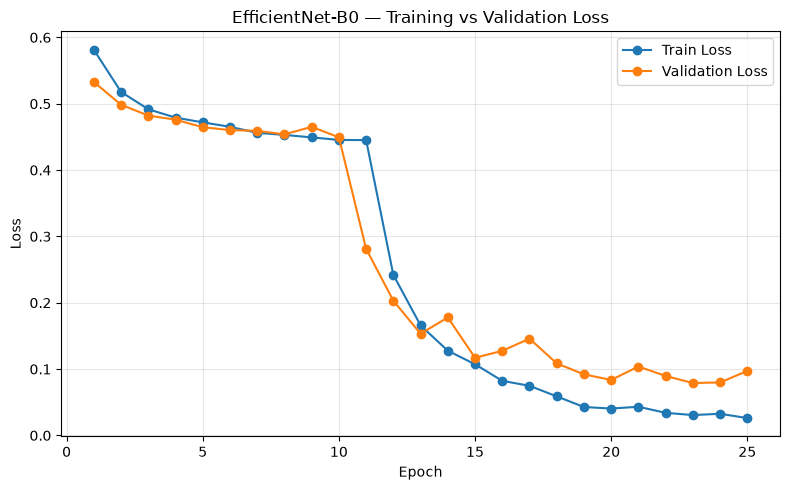

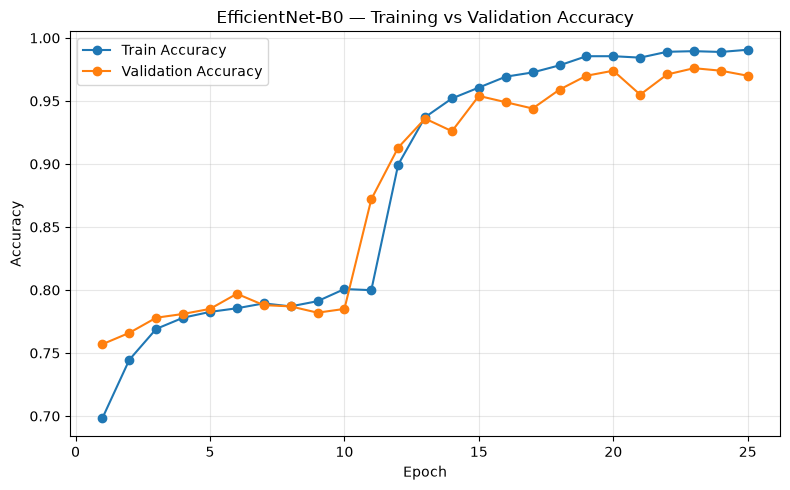

Saved: /content/drive/MyDrive/NNDL_Deepfake_Project/results/loss_curve.png
Saved: /content/drive/MyDrive/NNDL_Deepfake_Project/results/accuracy_curve.png


In [16]:
# Cell 16 — Plot training/validation loss and accuracy
import matplotlib.pyplot as plt

# Plot every epoch actually completed. These are raw curves; no smoothing is applied.
epochs = history["epoch"]

plt.figure(figsize=(8, 5))
plt.plot(epochs, history["train_loss"], marker="o", label="Train Loss")
plt.plot(epochs, history["val_loss"], marker="o", label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("EfficientNet-B0 — Training vs Validation Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
loss_path = os.path.join(RESULTS_DIR, "loss_curve.png")
plt.savefig(loss_path, dpi=200, bbox_inches="tight")
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(epochs, history["train_accuracy"], marker="o", label="Train Accuracy")
plt.plot(epochs, history["val_accuracy"], marker="o", label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("EfficientNet-B0 — Training vs Validation Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
acc_path = os.path.join(RESULTS_DIR, "accuracy_curve.png")
plt.savefig(acc_path, dpi=200, bbox_inches="tight")
plt.show()

print("Saved:", loss_path)
print("Saved:", acc_path)

HELD-OUT TEST RESULTS
----------------------------------------
loss      : 0.0801
accuracy  : 0.9690
precision : 0.9662
recall    : 0.9720
f1        : 0.9691
roc_auc   : 0.9963

Classification report (FAKE is the positive class):
              precision    recall  f1-score   support

        FAKE     0.9662    0.9720    0.9691       500
        REAL     0.9718    0.9660    0.9689       500

    accuracy                         0.9690      1000
   macro avg     0.9690    0.9690    0.9690      1000
weighted avg     0.9690    0.9690    0.9690      1000



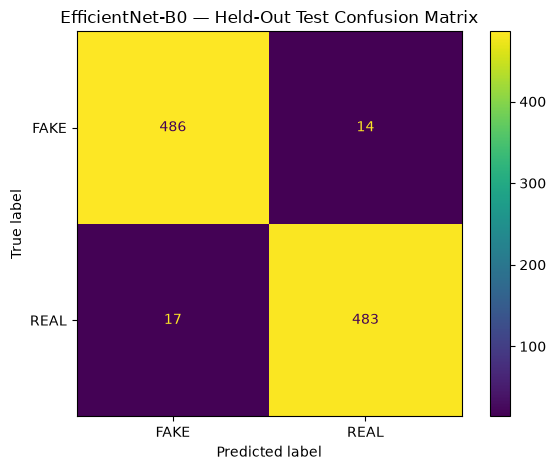

Saved: /content/drive/MyDrive/NNDL_Deepfake_Project/results/confusion_matrix.png
Saved: /content/drive/MyDrive/NNDL_Deepfake_Project/results/test_metrics.json


In [17]:
# Cell 17 — Final evaluation on the HELD-OUT TEST set
# This is the FIRST place where test performance is used.
# Test accuracy, precision, recall, F1, ROC-AUC and confusion matrix are reported.

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Keep the best checkpoint loaded.
model.eval()
test_metrics, test_labels, test_probs = run_epoch(model, test_loader)
test_preds = (test_probs >= 0.5).astype(int)

print("HELD-OUT TEST RESULTS")
print("-" * 40)
for key, value in test_metrics.items():
    print(f"{key:10s}: {value:.4f}")

print("\nClassification report (FAKE is the positive class):")
print(classification_report(
    test_labels, test_preds,
    labels=[1, 0],
    target_names=["FAKE", "REAL"],
    digits=4,
    zero_division=0
))

cm = confusion_matrix(test_labels, test_preds, labels=[1, 0])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["FAKE", "REAL"])
disp.plot(values_format="d")
plt.title("EfficientNet-B0 — Held-Out Test Confusion Matrix")
plt.tight_layout()
cm_path = os.path.join(RESULTS_DIR, "confusion_matrix.png")
plt.savefig(cm_path, dpi=200, bbox_inches="tight")
plt.show()

metrics_path = os.path.join(RESULTS_DIR, "test_metrics.json")
with open(metrics_path, "w") as f:
    json.dump({k: float(v) for k, v in test_metrics.items()}, f, indent=2)

print("Saved:", cm_path)
print("Saved:", metrics_path)

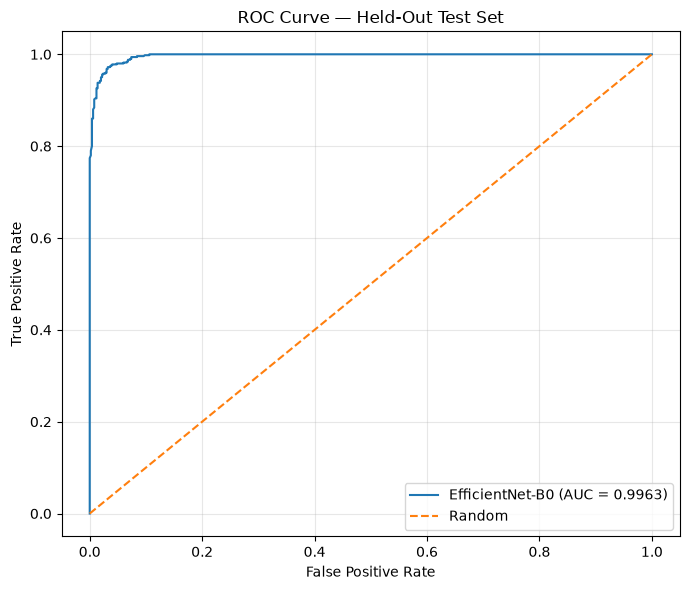

ROC-AUC: 0.9962639999999999
Saved: /content/drive/MyDrive/NNDL_Deepfake_Project/results/roc_curve.png


In [18]:
# Cell 18 — ROC curve and AUC on the held-out test set
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(test_labels, test_probs)
test_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, label=f"EfficientNet-B0 (AUC = {test_auc:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Held-Out Test Set")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
roc_path = os.path.join(RESULTS_DIR, "roc_curve.png")
plt.savefig(roc_path, dpi=200, bbox_inches="tight")
plt.show()

print("ROC-AUC:", test_auc)
print("Saved:", roc_path)

In [19]:
# Cell 19 — Save a compact final model file for inference/demo
final_model_path = os.path.join(CHECKPOINT_DIR, "efficientnet_b0_final.pth")

torch.save({
    "model_state_dict": model.state_dict(),
    "class_to_idx": train_dataset.class_to_idx,
    "image_size": IMAGE_SIZE,
    "imagenet_mean": IMAGENET_MEAN,
    "imagenet_std": IMAGENET_STD,
    "architecture": "efficientnet_b0",
    "target_convention": "FAKE=1, REAL=0",
    "best_checkpoint_epoch": int(best_ckpt["epoch"]),
    "best_checkpoint_stage": best_ckpt["stage"],
    "test_metrics": {k: float(v) for k, v in test_metrics.items()},
}, final_model_path)

print("Final model saved to:")
print(final_model_path)

Final model saved to:
/content/drive/MyDrive/NNDL_Deepfake_Project/checkpoints/efficientnet_b0_final.pth


In [20]:
# Cell 20 — Optional single-image inference
# Upload an unseen face image and get REAL/FAKE + probability of FAKE.
# The probability semantics are guaranteed by the explicit target mapping used in training.

from PIL import Image
from google.colab import files

uploaded = files.upload()
model.eval()

for filename in uploaded:
    image = Image.open(filename).convert("RGB")
    x = eval_transform(image).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        with torch.autocast(
            device_type=DEVICE.type,
            dtype=torch.float16 if DEVICE.type == "cuda" else torch.bfloat16,
            enabled=use_amp
        ):
            logit = model(x)
        fake_probability = torch.sigmoid(logit).item()

    predicted = "FAKE" if fake_probability >= 0.5 else "REAL"
    real_probability = 1.0 - fake_probability
    confidence = max(fake_probability, real_probability)

    print(f"Image: {filename}")
    print(f"Prediction: {predicted}")
    print(f"Probability of FAKE: {fake_probability:.4f}")
    print(f"Probability of REAL: {real_probability:.4f}")
    print(f"Confidence: {confidence:.4f}")

Saving test 2.jpeg to test 2.jpeg
Image: test 2.jpeg
Prediction: FAKE
Probability of FAKE: 0.7734
Probability of REAL: 0.2266
Confidence: 0.7734
